# nb_full_01 — Feature Analysis & Data Exploration

**Goal:** Understand all four input modalities of the TropiCycloneNet-D (TCND) dataset and the multi-task prediction targets.

| Modality | Shape | Description |
|---|---|---|
| `data_1d` | `(4,)` | Normalized [LONG, LAT, PRES, WND] at current timestep |
| `data_3d` | `(13, 81, 81)` | ERA5 patch — u×4, v×4, z×4, SST×1 |
| `env_data` | `(94,)` | Environmental context (month, area, intensity, location, history) |
| `phys_features` | `(8,)` | Physics priors for PhysIRM |

| Target | Shape | Description |
|---|---|---|
| `y_intensity` | scalar long | Intensity change class 24h ahead (0–3) |
| `y_direction` | scalar long | Movement direction class 24h ahead (0–7) |
| `y_wind_reg` | scalar float | Normalized wind 24h ahead |
| `y_pres_reg` | scalar float | Normalized pressure 24h ahead |
| `y_track_norm` | `(4, 2)` | [LONG_norm, LAT_norm] at t+6h..t+24h |

In [1]:
# ── Setup ────────────────────────────────────────────────────────────────────
import subprocess, sys, importlib
subprocess.run([sys.executable, "-m", "pip", "install", "seaborn", "netCDF4", "tqdm", "-q"],
               capture_output=True)

import os
from pathlib import Path

TOKEN = ""
REPO = f"https://{TOKEN}@github.com/Thiruvikraman07/ClimateChangeFinalProject.git"
ROOT = Path("/content/ClimateChangeFinalProject")
if not ROOT.exists():
    subprocess.run(["git", "clone", REPO, str(ROOT)], check=True)
else:
    subprocess.run(["git", "-C", str(ROOT), "pull"], check=True)

if str(ROOT / "final_src") not in sys.path:
    sys.path.insert(0, str(ROOT / "final_src"))
os.chdir(ROOT)

from google.colab import drive
drive.mount("/content/drive")
DATA_ROOT = Path("/content/drive/MyDrive/MLfTCC/Data/Tropicyclonenet/TestData/TCND_test")
# ↑ Change to TrainData path when using full dataset:
# DATA_ROOT = Path("/content/drive/MyDrive/MLfTCC/Data/Tropicyclonenet/TrainData")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from collections import defaultdict

import dataset.dataset, metrics.basin_metrics
importlib.reload(dataset.dataset)
importlib.reload(metrics.basin_metrics)

from dataset.dataset import TCNDDataset, BASIN_CODES, make_dataloader
from metrics.basin_metrics import INTENSITY_CLASSES, DIRECTION_CLASSES

BASINS = BASIN_CODES
COLORS = sns.color_palette("tab10", n_colors=6)
BC     = dict(zip(BASINS, COLORS))
DEVICE = (torch.device('cuda') if torch.cuda.is_available()
          else torch.device('mps') if torch.backends.mps.is_available()
          else torch.device('cpu'))
print(f"Device : {DEVICE}")
print(f"Basins : {BASINS}")

Mounted at /content/drive
Device : cuda
Basins : ['WP', 'NA', 'EP', 'NI', 'SI', 'SP']


In [2]:
# ── Prefetch Drive files to local SSD (run once per Colab session) ────────────
# If /content/tcnd_local already has data, just sets LOCAL_ROOT and skips copy.
# Otherwise copies all .nc/.npy/.txt from Drive to local SSD (~100x faster I/O).

from pathlib import Path
from dataset.dataset import prefetch_to_local

LOCAL_SSD = Path('/content/tcnd_local')

if (LOCAL_SSD / 'Data1D').exists():
    # Already prefetched this session — just reuse it
    LOCAL_ROOT = str(LOCAL_SSD)
    print(f'Local SSD already populated — skipping copy.')
    print(f'LOCAL_ROOT = {LOCAL_ROOT}')
else:
    # Detect split inline (load-ds has not run yet)
    _d1d = Path(DATA_ROOT) / 'Data1D'
    if not _d1d.exists():
        # Walk one level down in case root is a parent dir
        _hits = list(Path(DATA_ROOT).rglob('Data1D'))
        _d1d  = _hits[0] if _hits else _d1d
    _votes = []
    for _b in BASINS:
        _bd = _d1d / _b
        if _bd.exists():
            for _pref in ['train', 'val', 'test']:
                if (_bd / _pref).exists():
                    _votes.append(_pref); break
    from collections import Counter as _Ctr
    _split      = _Ctr(_votes).most_common(1)[0][0] if _votes else 'test'
    _force_kw   = {'force_split': _split} if _split in ('train', 'val') else {}
    print(f'Detected split for prefetch: {_split}')

    LOCAL_ROOT = prefetch_to_local(
        root        = DATA_ROOT,
        basins      = BASINS,
        split       = _split,
        local_dir   = str(LOCAL_SSD),
        n_workers   = 32,
        force_split = _force_kw.get('force_split'),
    )
    print(f'LOCAL_ROOT = {LOCAL_ROOT}')


Detected split for prefetch: test
Building index to collect file list...
✓ Index loaded from disk cache (12242 samples) — skipping full scan
Files to copy : 24,975  (4.33 GB)
Destination   : /content/tcnd_local
Workers       : 32


Copying to local SSD:   0%|          | 0/24975 [00:00<?, ?file/s]

Done — copied=24,975  skipped=0  errors=0
✓ Use this as DATA_ROOT for fast local training:
  '/content/tcnd_local'
LOCAL_ROOT = /content/tcnd_local


In [3]:
# Use LOCAL_ROOT if prefetch has run, else fall back to Drive
_data_root = globals().get("LOCAL_ROOT", DATA_ROOT)

# ── Detect which split to use (checks all basins, picks majority) ─────────────
def detect_split(data_root):
    root = Path(data_root)
    tcnd = root
    if not (tcnd / 'Data1D').exists():
        for sub in tcnd.iterdir():
            if sub.is_dir() and (sub / 'Data1D').exists():
                tcnd = sub; break

    split_votes = []
    for basin in BASINS:
        basin_dir = tcnd / 'Data1D' / basin
        if not basin_dir.exists(): continue
        available = sorted([d.name for d in basin_dir.iterdir() if d.is_dir()])
        for preferred in ['train', 'val', 'test']:
            if preferred in available:
                split_votes.append(preferred)
                break

    if not split_votes:
        return 'train', {}

    from collections import Counter
    chosen = Counter(split_votes).most_common(1)[0][0]
    print(f'Split votes across basins: {dict(Counter(split_votes))}')

    if chosen in ('train', 'val'):
        print(f'Using split="{chosen}" (force_split set — no fallback to test)')
        return chosen, {'force_split': chosen}

    print('⚠️  WARNING: Only "test/" split found in your data.')
    print('   This notebook will load test data for exploration.')
    return 'test', {}

EXPLORE_SPLIT, FORCE_SPLIT_KW = detect_split(DATA_ROOT)

# ── Load dataset ──────────────────────────────────────────────────────────────
ds = TCNDDataset(
    root    = _data_root,
    basins  = BASINS,
    split   = EXPLORE_SPLIT,
    use_3d  = True,
    use_env = True,
    **FORCE_SPLIT_KW,
)
print(f'\nTotal samples ({EXPLORE_SPLIT}): {len(ds):,}')
print(f'Sample keys : {list(ds[0].keys())}')

basin_n = defaultdict(int)
for m in ds.index:
    basin_n[m['basin']] += 1
print(f'\nPer-basin counts ({EXPLORE_SPLIT}):')
for b in BASINS:
    print(f'  {b}: {basin_n[b]:,}')

Split votes across basins: {'test': 6}
⚠️  WARNING: Only "test/" split found in your data.
   This notebook will load test data for exploration.


Indexing (parallel):   0%|          | 0/488 [00:00<?, ?it/s]

✓ Index saved to disk cache → next run will be instant (96be7a325d9a.pkl)

Total samples (test): 12,242
Sample keys : ['data_1d', 'data_3d', 'env_data', 'phys_features', 'basin_idx', 'y_intensity', 'y_direction', 'y_wind_reg', 'y_pres_reg', 'y_track_norm']

Per-basin counts (test):
  WP: 2,726
  NA: 3,467
  EP: 2,929
  NI: 447
  SI: 1,990
  SP: 683


## 1 — Data_1D: Normalized Tabular Features by Basin

Denormalization: `WND_ms = WND_norm × 25 + 40`,  `PRES_hPa = PRES_norm × 50 + 960`

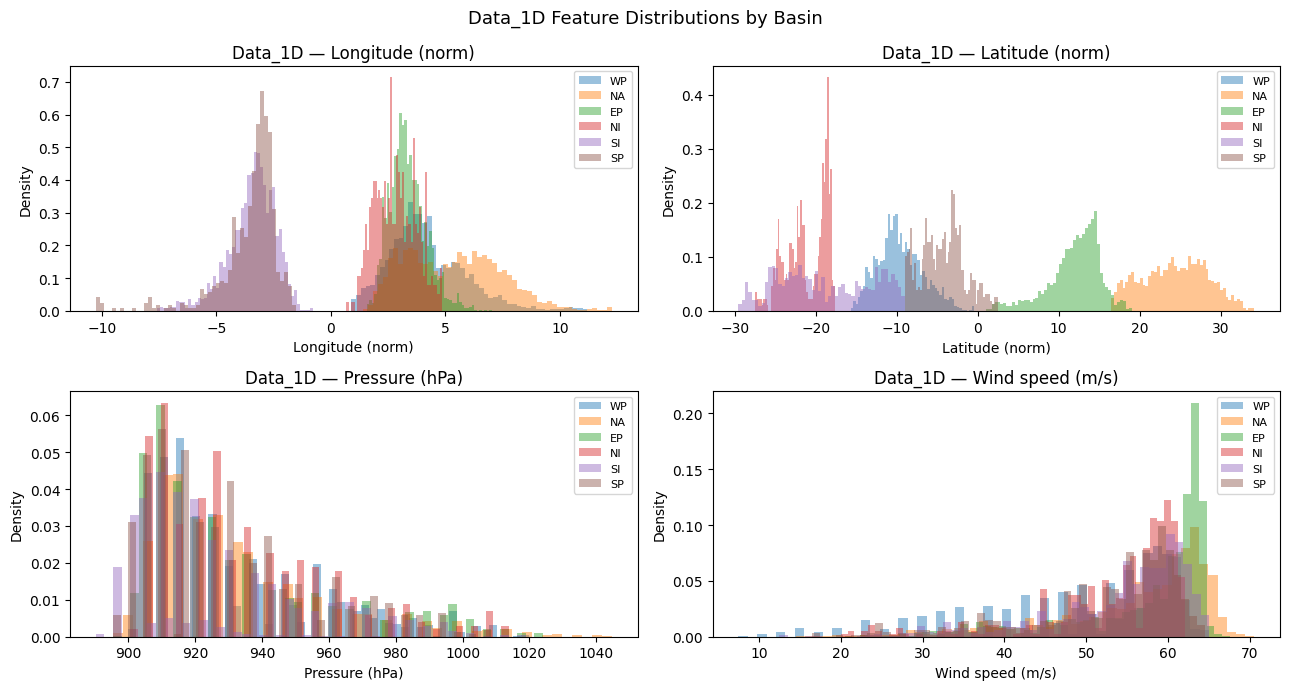

In [12]:
b1d = defaultdict(lambda: dict(long=[], lat=[], pres=[], wnd=[]))
for m in ds.index:
    b, r = m['basin'], m['csv_row']
    b1d[b]['long'].append(float(r.get('LONG_norm', np.nan)))
    b1d[b]['lat' ].append(float(r.get('LAT_norm',  np.nan)))
    b1d[b]['pres'].append(float(r.get('PRES_norm', np.nan)) * 50 + 960)
    b1d[b]['wnd' ].append(float(r.get('WND_norm',  np.nan)) * 25 + 40)

feat_labels = dict(long='Longitude (norm)', lat='Latitude (norm)',
                   pres='Pressure (hPa)',   wnd='Wind speed (m/s)')

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, (feat, lbl) in zip(axes.flatten(), feat_labels.items()):
    for b in BASINS:
        v = [x for x in b1d[b][feat] if np.isfinite(x)]
        if v: ax.hist(v, bins=50, alpha=0.45, label=b, color=BC[b], density=True)
    ax.set_xlabel(lbl); ax.set_ylabel('Density'); ax.set_title(f'Data_1D — {lbl}')
    ax.legend(fontsize=8)
plt.suptitle('Data_1D Feature Distributions by Basin', fontsize=13)
plt.tight_layout()
plt.savefig('nb_full_01_feat1d.png', dpi=120, bbox_inches='tight')
plt.show()

## 2 — Data_3D: ERA5 Spatial Patches (13 × 81 × 81)

Channels: u@{850,500,300,200hPa}, v@{850,500,300,200hPa}, z@{850,500,300,200hPa}, SST

Basins with 3D data: ['WP', 'NA', 'EP', 'NI', 'SI', 'SP']


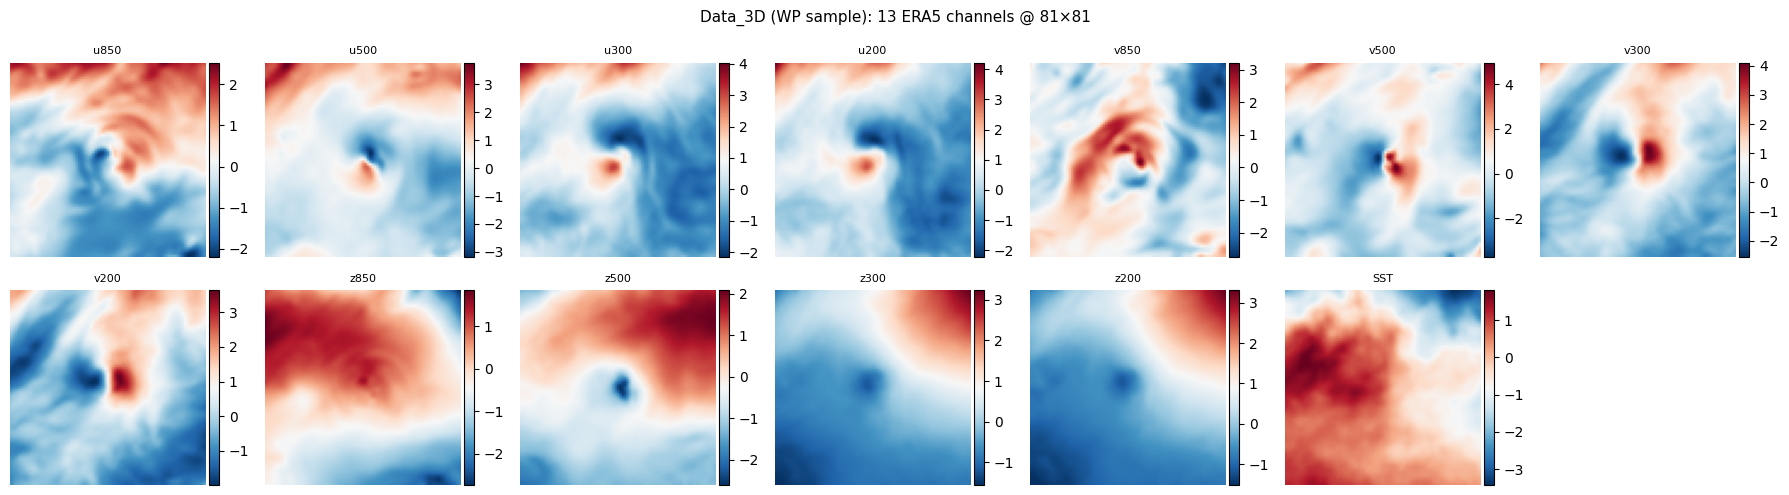

Data_3D shape: (13, 81, 81)
  u850      mean=+0.000  std=1.000
  u500      mean=+0.000  std=1.000
  u300      mean=-0.000  std=1.000
  u200      mean=+0.000  std=1.000
  v850      mean=-0.000  std=1.000
  v500      mean=+0.000  std=1.000
  v300      mean=+0.000  std=1.000
  v200      mean=+0.000  std=1.000
  z850      mean=-0.000  std=1.000
  z500      mean=+0.000  std=1.000
  z300      mean=-0.000  std=1.000
  z200      mean=+0.000  std=1.000
  SST       mean=+0.000  std=1.000


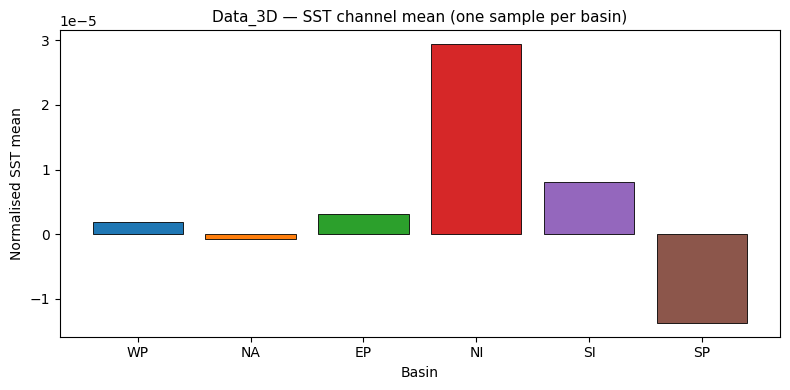

In [13]:
CH_NAMES = ([f'u{p}' for p in [850,500,300,200]] +
            [f'v{p}' for p in [850,500,300,200]] +
            [f'z{p}' for p in [850,500,300,200]] + ['SST'])

# ── Show one 3D sample per basin ──────────────────────────────────────────────
basin_samples = {}
for i, m in enumerate(ds.index):
    b = m['basin']
    if b not in basin_samples:
        basin_samples[b] = ds[i]
    if len(basin_samples) == len(BASINS):
        break

active_3d = [b for b in BASINS if b in basin_samples]
print(f'Basins with 3D data: {active_3d}')
if not active_3d:
    print('No 3D samples found.')
else:
    # Show all 13 channels for the first available basin
    ref_basin = active_3d[0]
    d3d = basin_samples[ref_basin]['data_3d'].numpy()
    fig, axes = plt.subplots(2, 7, figsize=(18, 5))
    for ax, ch, nm in zip(axes.flatten(), range(13), CH_NAMES):
        im = ax.imshow(d3d[ch], cmap='RdBu_r', aspect='auto')
        ax.set_title(nm, fontsize=8); ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
    for ax in axes.flatten()[13:]:
        ax.axis('off')
    plt.suptitle(f'Data_3D ({ref_basin} sample): 13 ERA5 channels @ 81×81', fontsize=11)
    plt.tight_layout()
    plt.savefig('nb_full_01_feat3d.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Data_3D shape: {d3d.shape}')
    for i, nm in enumerate(CH_NAMES):
        c = d3d[i]
        print(f'  {nm:8s}  mean={c.mean():+.3f}  std={c.std():.3f}')

    # ── Per-basin SST comparison (one representative sample per basin) ─────────
    sst_means = {b: basin_samples[b]['data_3d'].numpy()[-1].mean() for b in active_3d}
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(list(sst_means.keys()), list(sst_means.values()),
           color=[BC[b] for b in sst_means], edgecolor='k', linewidth=0.6)
    ax.set_title('Data_3D — SST channel mean (one sample per basin)', fontsize=11)
    ax.set_ylabel('Normalised SST mean'); ax.set_xlabel('Basin')
    plt.tight_layout()
    plt.savefig('nb_full_01_feat3d_sst.png', dpi=120, bbox_inches='tight')
    plt.show()

## 3 — Env-Data: 94-dim Environmental Context

`[0:12]` month · `[12:18]` area · `[18:24]` intensity_class · `[24:26]` wind, velocity · `[26:74]` location · `[74:94]` history directions & intensity

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: pin_memory_device is deprecated, the current accelerator will be used as the device,ignore pin_memory_device='cuda'.
  super().__init__(loader)


Basins with env data: ['WP', 'NA', 'EP', 'NI', 'SI', 'SP']
Samples per basin: {'WP': 400, 'NA': 400, 'EP': 400, 'NI': 400, 'SI': 400, 'SP': 400}


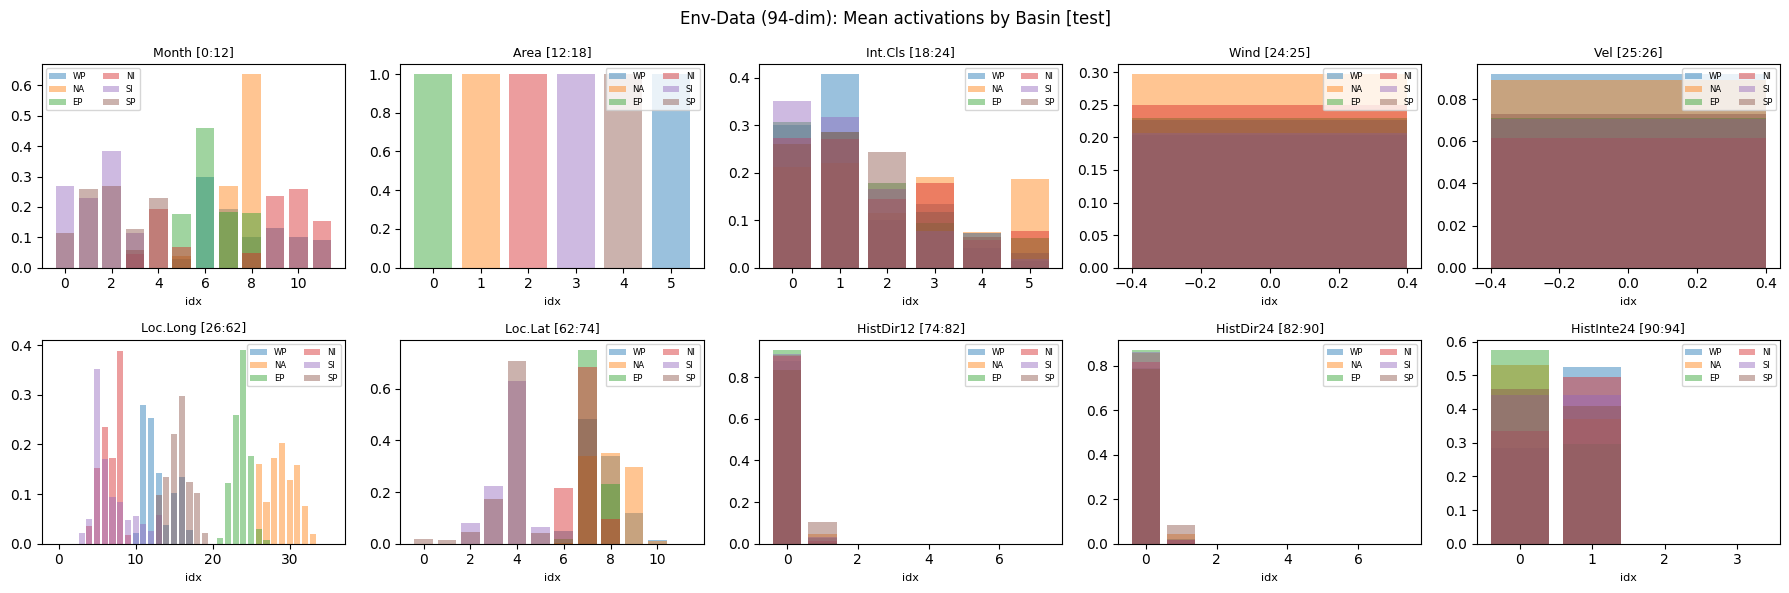

In [14]:
loader = make_dataloader(globals().get("LOCAL_ROOT", DATA_ROOT), BASINS, split=EXPLORE_SPLIT,
                         batch_size=256, num_workers=0,
                         use_3d=False, use_env=True,
                         **FORCE_SPLIT_KW)

env_acc = defaultdict(list)
cnt = defaultdict(int)
LIMIT = 400
# Only break when all basins that HAVE data have reached the limit
with torch.no_grad():
    for batch in loader:
        if batch is None: continue
        for i in range(batch['basin_idx'].shape[0]):
            b = BASIN_CODES[batch['basin_idx'][i].item()]
            if cnt[b] < LIMIT:
                env_acc[b].append(batch['env_data'][i].numpy())
                cnt[b] += 1

env_mean = {b: np.stack(env_acc[b]).mean(0) for b in BASINS if env_acc[b]}
print(f'Basins with env data: {list(env_mean.keys())}')
print(f'Samples per basin: { {b: len(env_acc[b]) for b in env_mean} }')

SLICES = [('Month',0,12),('Area',12,18),('Int.Cls',18,24),('Wind',24,25),
          ('Vel',25,26),('Loc.Long',26,62),('Loc.Lat',62,74),
          ('HistDir12',74,82),('HistDir24',82,90),('HistInte24',90,94)]

fig, axes = plt.subplots(2, 5, figsize=(18, 6))
for ax, (nm, s, e) in zip(axes.flatten(), SLICES):
    for b in BASINS:
        if b in env_mean:
            seg = env_mean[b][s:e]
            ax.bar(range(len(seg)), seg, alpha=0.45, label=b, color=BC[b])
    ax.set_title(f'{nm} [{s}:{e}]', fontsize=9)
    ax.set_xlabel('idx', fontsize=8); ax.legend(fontsize=6, ncol=2)
plt.suptitle(f'Env-Data (94-dim): Mean activations by Basin [{EXPLORE_SPLIT}]', fontsize=12)
plt.tight_layout()
plt.savefig('nb_full_01_env.png', dpi=120, bbox_inches='tight')
plt.show()

## 4 — Physics Features (8-dim)

`[SST_mean, SST_std, Coriolis_f, u850_mean, v850_mean, z850_mean, RH_proxy, VWS]` — designed to be physically meaningful across basins.

Basins with phys data: ['WP', 'NA', 'EP', 'NI', 'SI', 'SP']


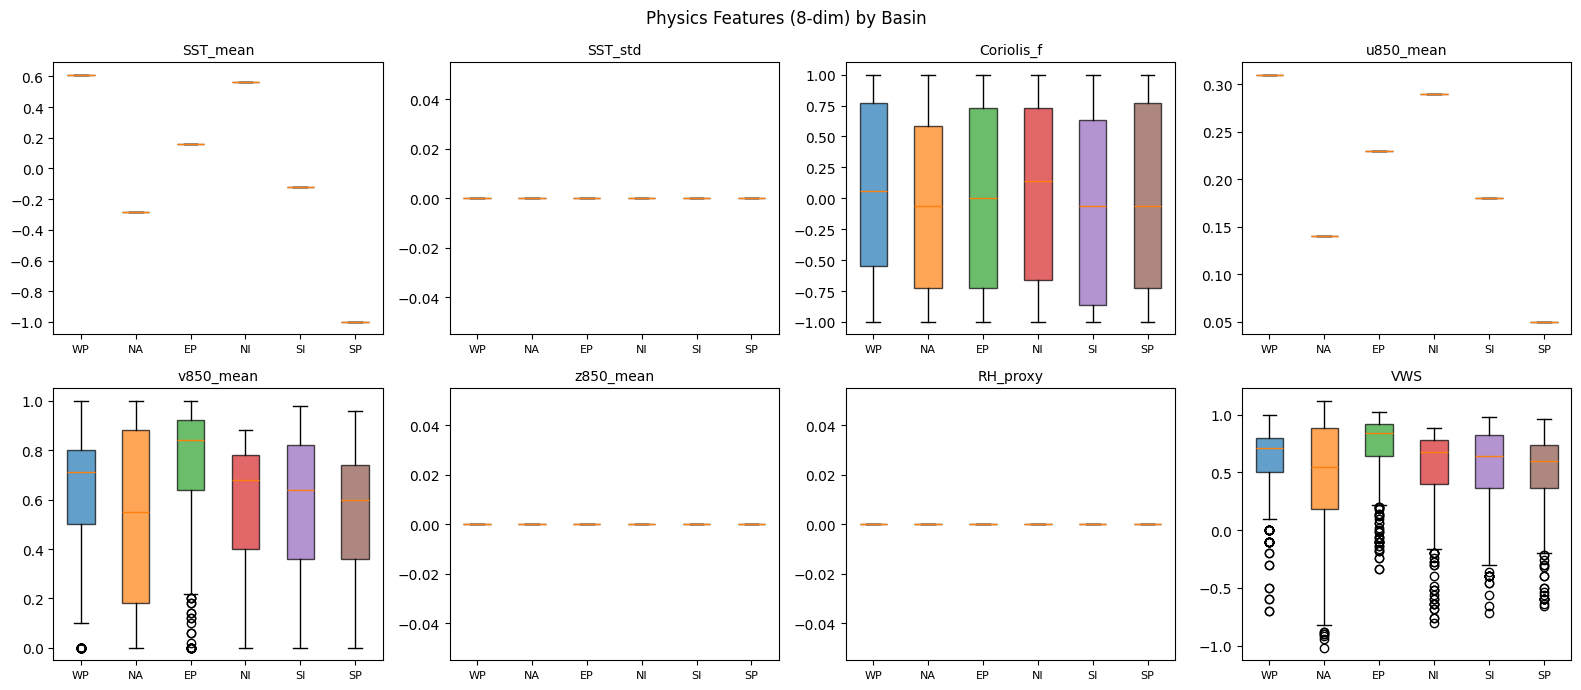

In [15]:
PHYS_NAMES = ['SST_mean','SST_std','Coriolis_f','u850_mean','v850_mean','z850_mean','RH_proxy','VWS']

phys_acc = defaultdict(list)
cnt = defaultdict(int)
with torch.no_grad():
    for batch in loader:
        if batch is None: continue
        for i in range(batch['basin_idx'].shape[0]):
            b = BASIN_CODES[batch['basin_idx'][i].item()]
            if cnt[b] < LIMIT:
                phys_acc[b].append(batch['phys_features'][i].numpy())
                cnt[b] += 1

active_basins = [b for b in BASINS if phys_acc[b]]
print(f'Basins with phys data: {active_basins}')
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for j, (ax, nm) in enumerate(zip(axes.flatten(), PHYS_NAMES)):
    data = [np.array(phys_acc[b])[:, j] for b in active_basins]
    bp = ax.boxplot(data, tick_labels=active_basins, patch_artist=True)
    for patch, b in zip(bp['boxes'], active_basins):
        patch.set_facecolor(BC[b]); patch.set_alpha(0.7)
    ax.set_title(nm, fontsize=10); ax.tick_params(axis='x', labelsize=8)
plt.suptitle('Physics Features (8-dim) by Basin', fontsize=12)
plt.tight_layout()
plt.savefig('nb_full_01_phys.png', dpi=120, bbox_inches='tight')
plt.show()

## 5 — Target Variable Distributions

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: pin_memory_device is deprecated, the current accelerator will be used as the device,ignore pin_memory_device='cuda'.
  super().__init__(loader)


Basins with target data: ['WP', 'NA', 'EP', 'NI', 'SI', 'SP']
Samples per basin: {'WP': 800, 'NA': 800, 'EP': 800, 'NI': 447, 'SI': 800, 'SP': 683}


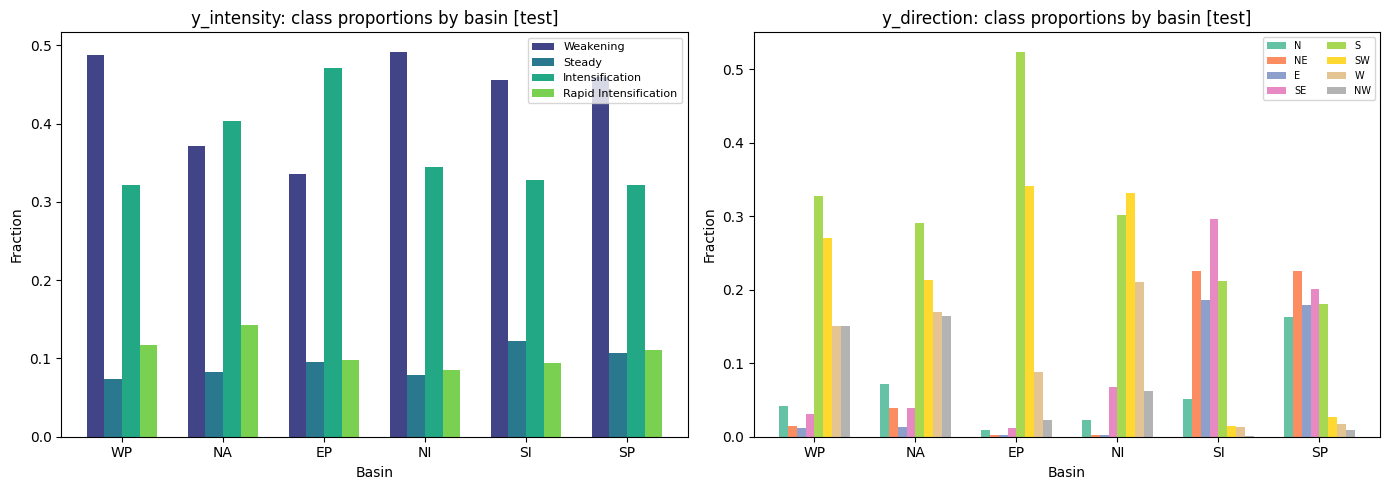

In [16]:
loader2 = make_dataloader(globals().get("LOCAL_ROOT", DATA_ROOT), BASINS, split=EXPLORE_SPLIT,
                          batch_size=256, num_workers=0,
                          use_3d=False, use_env=False,
                          **FORCE_SPLIT_KW)
tgt = defaultdict(lambda: dict(y_int=[], y_dir=[], y_wnd=[], y_prs=[], y_trk=[]))
cnt = defaultdict(int)
LIMIT2 = 800
with torch.no_grad():
    for batch in loader2:
        if batch is None: continue
        for i in range(batch['basin_idx'].shape[0]):
            b = BASIN_CODES[batch['basin_idx'][i].item()]
            if cnt[b] < LIMIT2:
                tgt[b]['y_int'].append(batch['y_intensity'][i].item())
                tgt[b]['y_dir'].append(batch['y_direction'][i].item())
                tgt[b]['y_wnd'].append(batch['y_wind_reg'][i].item())
                tgt[b]['y_prs'].append(batch['y_pres_reg'][i].item())
                tgt[b]['y_trk'].append(batch['y_track_norm'][i].numpy())
                cnt[b] += 1

active_tgt = [b for b in BASINS if tgt[b]['y_int']]
print(f'Basins with target data: {active_tgt}')
print(f'Samples per basin: { {b: cnt[b] for b in active_tgt} }')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
int_frac = {b: np.bincount(np.array(tgt[b]['y_int'], dtype=int), minlength=4) / max(1, len(tgt[b]['y_int'])) for b in active_tgt}
pd.DataFrame(int_frac, index=[INTENSITY_CLASSES[k] for k in range(4)]).T.plot(
    kind='bar', ax=axes[0], color=sns.color_palette('viridis', 4), width=0.7)
axes[0].set_title(f'y_intensity: class proportions by basin [{EXPLORE_SPLIT}]')
axes[0].set_xlabel('Basin'); axes[0].set_ylabel('Fraction'); axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=8)
dir_frac = {b: np.bincount(np.array(tgt[b]['y_dir'], dtype=int), minlength=8) / max(1, len(tgt[b]['y_dir'])) for b in active_tgt}
pd.DataFrame(dir_frac, index=DIRECTION_CLASSES).T.plot(
    kind='bar', ax=axes[1], color=sns.color_palette('Set2', 8), width=0.7)
axes[1].set_title(f'y_direction: class proportions by basin [{EXPLORE_SPLIT}]')
axes[1].set_xlabel('Basin'); axes[1].set_ylabel('Fraction'); axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.savefig('nb_full_01_class_targets.png', dpi=120, bbox_inches='tight')
plt.show()

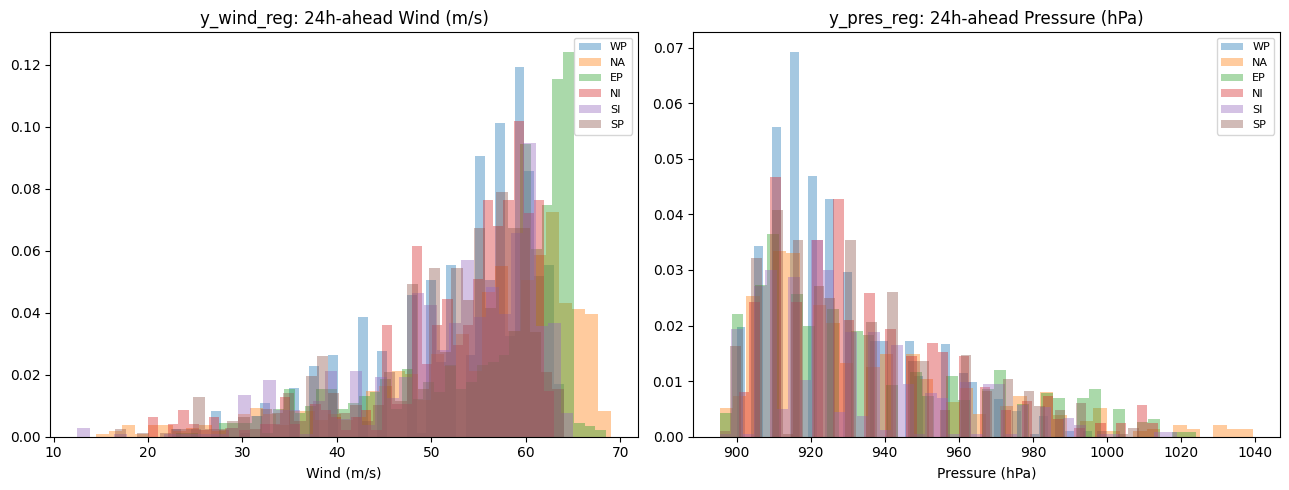

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for b in BASINS:
    wnd = [x*25+40 for x in tgt[b]['y_wnd'] if np.isfinite(x)]
    prs = [x*50+960 for x in tgt[b]['y_prs'] if np.isfinite(x)]
    if wnd: axes[0].hist(wnd, bins=40, alpha=0.4, label=b, density=True, color=BC[b])
    if prs: axes[1].hist(prs, bins=40, alpha=0.4, label=b, density=True, color=BC[b])
axes[0].set_title('y_wind_reg: 24h-ahead Wind (m/s)')
axes[0].set_xlabel('Wind (m/s)'); axes[0].legend(fontsize=8)
axes[1].set_title('y_pres_reg: 24h-ahead Pressure (hPa)')
axes[1].set_xlabel('Pressure (hPa)'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig('nb_full_01_reg_targets.png', dpi=120, bbox_inches='tight')
plt.show()

## 6 — Track Target: y_track_norm (4, 2)

The `track_head` inside `TropiCycloneModel` predicts these future positions from the **same multimodal backbone representation `z`** as intensity, direction, and regression heads.

NaN entries mark steps beyond storm end — masked out during training.

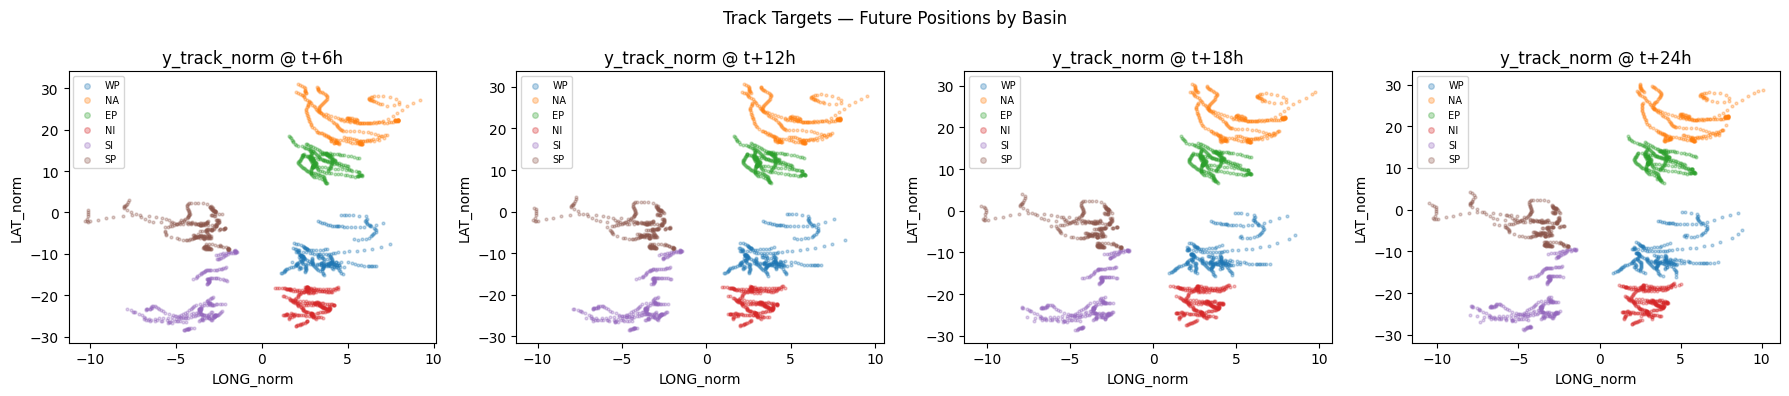


Valid track step fraction (non-NaN) per basin:
Basin   t+6h    t+12h   t+18h   t+24h 
WP      1.000  1.000  1.000  1.000
NA      1.000  1.000  1.000  1.000
EP      1.000  1.000  1.000  1.000
NI      1.000  1.000  1.000  1.000
SI      1.000  1.000  1.000  1.000
SP      1.000  1.000  1.000  1.000


In [18]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
STEP_LABELS = ['t+6h', 't+12h', 't+18h', 't+24h']
for step_i, (ax, lbl) in enumerate(zip(axes, STEP_LABELS)):
    for b in BASINS:
        trks = tgt[b]['y_trk']
        lons = [t[step_i, 0] for t in trks if np.isfinite(t[step_i, 0])]
        lats = [t[step_i, 1] for t in trks if np.isfinite(t[step_i, 1])]
        if lons:
            ax.scatter(lons[:300], lats[:300], s=4, alpha=0.3, color=BC[b], label=b)
    ax.set_title(f'y_track_norm @ {lbl}'); ax.set_xlabel('LONG_norm'); ax.set_ylabel('LAT_norm')
    ax.legend(fontsize=7, markerscale=2)
plt.suptitle('Track Targets — Future Positions by Basin', fontsize=12)
plt.tight_layout()
plt.savefig('nb_full_01_track.png', dpi=120, bbox_inches='tight')
plt.show()

print('\nValid track step fraction (non-NaN) per basin:')
header = f'{"Basin":6s}' + ''.join(f'  {s:6s}' for s in STEP_LABELS)
print(header)
for b in BASINS:
    if not tgt[b]['y_trk']:
        print(f'{b:6s}  (no data)')
        continue
    arr = np.stack(tgt[b]['y_trk'])  # (N,4,2)
    fracs = np.isfinite(arr[:, :, 0]).mean(0)
    print(f'{b:6s}' + ''.join(f'  {f:.3f}' for f in fracs))

## 7 — Summary

In [19]:
rows = []
for b in BASINS:
    yi = tgt[b]['y_int']
    if not yi:
        print(f'  {b}: no data')
        continue
    c = np.bincount(np.array(yi, dtype=int), minlength=4)
    rows.append({
        'Basin': b,
        'N (index)': basin_n[b],
        'N (sampled)': len(yi),
        'Weaken%': f'{c[0]/len(yi)*100:.1f}',
        'Steady%': f'{c[1]/len(yi)*100:.1f}',
        'Inten%':  f'{c[2]/len(yi)*100:.1f}',
        'RI%':     f'{c[3]/len(yi)*100:.1f}',
        'Avg WND': f'{np.nanmean([x*25+40 for x in tgt[b]["y_wnd"]]):.1f} m/s',
        'Avg PRES': f'{np.nanmean([x*50+960 for x in tgt[b]["y_prs"]]):.1f} hPa',
    })
print(pd.DataFrame(rows).to_string(index=False))
print(f'\nModalities : data_1d(4) + data_3d(13×81×81) + env_data(94) + phys_features(8)')
print(f'Targets    : y_intensity(0-3) + y_direction(0-7) + y_wind_reg + y_pres_reg + y_track_norm(4,2)')
print(f'Backbone   : TropiCycloneModel → z(128) → 4× TaskHeads')

Basin  N (index)  N (sampled) Weaken% Steady% Inten%  RI%  Avg WND  Avg PRES
   WP       2726          800    48.8     7.4   32.1 11.8 53.7 m/s 926.6 hPa
   NA       3467          800    37.1     8.2   40.4 14.2 54.7 m/s 936.6 hPa
   EP       2929          800    33.6     9.5   47.1  9.8 55.7 m/s 937.4 hPa
   NI        447          447    49.2     7.8   34.5  8.5 53.0 m/s 935.4 hPa
   SI       1990          800    45.6    12.2   32.8  9.4 52.0 m/s 930.7 hPa
   SP        683          683    46.0    10.7   32.2 11.1 51.0 m/s 932.9 hPa

Modalities : data_1d(4) + data_3d(13×81×81) + env_data(94) + phys_features(8)
Targets    : y_intensity(0-3) + y_direction(0-7) + y_wind_reg + y_pres_reg + y_track_norm(4,2)
Backbone   : TropiCycloneModel → z(128) → 4× TaskHeads


## 8 — Feature Selection: Gradient-Based Importance

**Which input features matter most?** We compute the gradient of the combined task loss w.r.t. each input dimension using a trained ERM model. Higher |∇| → the model is more sensitive to that feature.

We analyse three modalities:
1. **Data_1D (4-dim)** — which of [LONG, LAT, PRES, WND] matters most?
2. **Data_3D channels (13)** — which ERA5 channel does the model attend to most?
3. **Env-Data segments** — which of the 10 env-data blocks drives predictions?

In [20]:
import models.backbone, methods.dg_methods
importlib.reload(models.backbone)
importlib.reload(methods.dg_methods)

from models.backbone import TropiCycloneModel
from methods.dg_methods import build_method, task_loss
from dataset.dataset import make_per_basin_loaders
import torch.nn.functional as F

DEVICE = (torch.device("cuda") if torch.cuda.is_available()
          else torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cpu"))

# ── Quick ERM probe ───────────────────────────────────────────────────────────
PROBE_EPOCHS = 5
model = TropiCycloneModel.build(use_3d=True, use_env=True).to(DEVICE)
method = build_method("erm", reg_weight=0.5, track_weight=0.5)

_train_root = globals().get("LOCAL_ROOT", DATA_ROOT)

loaders = make_per_basin_loaders(_train_root, BASINS,
                                 split=EXPLORE_SPLIT,
                                 batch_size=128, num_workers=2,
                                 use_3d=True, use_env=True,
                                 **FORCE_SPLIT_KW)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print(f"Data root         : {_train_root}")
print(f"Basins in loaders : {list(loaders.keys())}")
print(f"Batches per basin : { {b: len(loaders[b]) for b in loaders} }")
print(f"Device            : {DEVICE}")
n_params = sum(p.numel() for p in model.parameters())
print(f"Model params      : {n_params:,}")
print()

HDR = f"{{"Ep":>3}}  {{"total":>7}}  {{"int_ce":>7}}  {{"dir_ce":>7}}  {{"reg":>7}}  {{"track":>7}}  {{"batches":>7}}"
print(HDR)
print("-" * len(HDR))

model.train()
for epoch in range(PROBE_EPOCHS):
    acc = dict(total=0., int_ce=0., dir_ce=0., reg=0., track=0.)
    n_batches = 0

    for b, loader in loaders.items():
        for batch in loader:
            if batch is None: continue
            batch = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}

            optimizer.zero_grad(set_to_none=True)
            out = model(batch)

            l_int = F.cross_entropy(out["logits_intensity"], batch["y_intensity"])
            l_dir = F.cross_entropy(out["logits_direction"], batch["y_direction"])
            loss  = l_int + 0.5 * l_dir

            l_reg = torch.tensor(0., device=DEVICE)
            if out.get("pred_intensity_reg") is not None:
                y_reg = torch.stack([batch["y_wind_reg"], batch["y_pres_reg"]], dim=-1)
                mask  = torch.isfinite(y_reg).all(dim=-1)
                if mask.sum() > 0:
                    l_reg = F.mse_loss(out["pred_intensity_reg"][mask], y_reg[mask])
                    loss  = loss + 0.5 * l_reg

            l_track = torch.tensor(0., device=DEVICE)
            if out.get("pred_track") is not None:
                step_mask = torch.isfinite(batch["y_track_norm"]).all(dim=-1)
                if step_mask.any():
                    err     = F.mse_loss(out["pred_track"], batch["y_track_norm"], reduction="none")
                    l_track = err.mean(dim=-1)[step_mask].mean()
                    loss    = loss + 0.5 * l_track

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            acc["total"]  += loss.item()
            acc["int_ce"] += l_int.item()
            acc["dir_ce"] += l_dir.item()
            acc["reg"]    += l_reg.item()
            acc["track"]  += l_track.item()
            n_batches += 1

    n = max(1, n_batches)
    print(f"{epoch+1:>3}  "
          f"{acc["total"]/n:>7.4f}  "
          f"{acc["int_ce"]/n:>7.4f}  "
          f"{acc["dir_ce"]/n:>7.4f}  "
          f"{acc["reg"]/n:>7.4f}  "
          f"{acc["track"]/n:>7.4f}  "
          f"{n_batches:>7d}")

print(f"
Probe trained on [{EXPLORE_SPLIT}] ({PROBE_EPOCHS} epochs).")


Indexing (parallel):   0%|          | 0/145 [00:00<?, ?it/s]

✓ Index saved to disk cache → next run will be instant (c34c588cea1e.pkl)


Indexing (parallel):   0%|          | 0/108 [00:00<?, ?it/s]

✓ Index saved to disk cache → next run will be instant (38d216d92667.pkl)


Indexing (parallel):   0%|          | 0/104 [00:00<?, ?it/s]

...

✓ Index saved to disk cache → next run will be instant (2f56e175f4b7.pkl)


Indexing (parallel):   0%|          | 0/30 [00:00<?, ?it/s]

✓ Index saved to disk cache → next run will be instant (8281af9823be.pkl)
Data root         : /content/tcnd_local
Basins in loaders : ['WP', 'NA', 'EP', 'NI', 'SI', 'SP']
Batches per basin : {'WP': 22, 'NA': 28, 'EP': 23, 'NI': 4, 'SI': 16, 'SP': 6}
Device            : cuda
Model params      : 629,014

 Ep    total   int_ce   dir_ce      reg    track  batches
---------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: pin_memory_device is deprecated, the current accelerator will be used as the device,ignore pin_memory_device='cuda'.
  super().__init__(loader)


  1  93.8300   1.2815   1.9378   0.4205  182.7387       99
  2  92.5881   1.2599   1.9236   0.2656  180.4673       99
  3  113.2800   1.2044   1.9409   0.2329  221.9775       99
  4  85.9485   1.1906   1.9299   0.2628  167.3233       99
  5  33.8577   1.2665   1.9203   0.3379  62.9243       99

Probe trained on [test] (5 epochs).


In [21]:
# ── Gradient sensitivity: accumulate |∂loss/∂x| over N batches ───────────────
model.eval()
N_GRAD_BATCHES = 20

grad_acc = {'data_1d': None, 'data_3d': None, 'env_data': None}
grad_cnt = 0

probe_loader = make_dataloader(globals().get("LOCAL_ROOT", DATA_ROOT), BASINS,
                               split=EXPLORE_SPLIT,
                               batch_size=64, num_workers=0,
                               use_3d=True, use_env=True,
                               **FORCE_SPLIT_KW)

for batch_i, batch in enumerate(probe_loader):
    if batch is None or batch_i >= N_GRAD_BATCHES:
        break

    d1d = batch['data_1d'      ].to(DEVICE).requires_grad_(True)
    d3d = batch['data_3d'      ].to(DEVICE).requires_grad_(True)
    env = batch['env_data'     ].to(DEVICE).requires_grad_(True)
    phys= batch['phys_features'].to(DEVICE)

    batch_fwd = {k: v.to(DEVICE) if isinstance(v, torch.Tensor) else v
                 for k, v in batch.items()}
    batch_fwd['data_1d'      ] = d1d
    batch_fwd['data_3d'      ] = d3d
    batch_fwd['env_data'     ] = env
    batch_fwd['phys_features'] = phys

    out  = model(batch_fwd)
    loss = task_loss(
        logits_int   = out['logits_intensity'],
        logits_dir   = out['logits_direction'],
        pred_reg     = out['pred_intensity_reg'],
        y_int        = batch_fwd['y_intensity'],
        y_dir        = batch_fwd['y_direction'],
        y_wind_reg   = batch_fwd['y_wind_reg'],
        y_pres_reg   = batch_fwd['y_pres_reg'],
        pred_track   = out['pred_track'],
        y_track_norm = batch_fwd['y_track_norm'],
        reg_weight   = 0.5,
        track_weight = 0.5,
    )
    loss.backward()

    with torch.no_grad():
        for key, inp in [('data_1d', d1d), ('data_3d', d3d), ('env_data', env)]:
            if inp.grad is not None:
                g = inp.grad.abs().mean(0).cpu()
                grad_acc[key] = g if grad_acc[key] is None else grad_acc[key] + g

    if d1d.grad is not None: d1d.grad.zero_()
    if d3d.grad is not None: d3d.grad.zero_()
    if env.grad is not None: env.grad.zero_()
    grad_cnt += 1

for k in grad_acc:
    if grad_acc[k] is not None:
        grad_acc[k] = (grad_acc[k] / grad_cnt).numpy()

print(f'Gradient sensitivity computed over {grad_cnt} batches [{EXPLORE_SPLIT}].')

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: pin_memory_device is deprecated, the current accelerator will be used as the device,ignore pin_memory_device='cuda'.
  super().__init__(loader)


Gradient sensitivity computed over 20 batches [test].


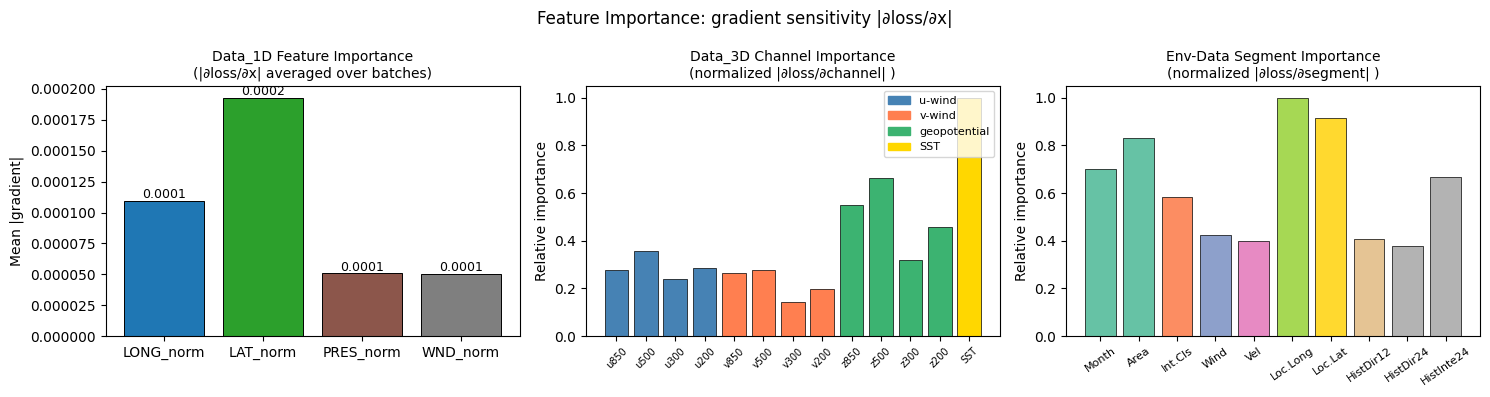

In [22]:
# ── Plot 1: Data_1D — per-feature importance ──────────────────────────────────
D1D_NAMES = ['LONG_norm', 'LAT_norm', 'PRES_norm', 'WND_norm']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Data_1D
if grad_acc['data_1d'] is not None:
    imp_1d = grad_acc['data_1d']   # shape (4,)
    axes[0].bar(D1D_NAMES, imp_1d, color=plt.get_cmap('tab10')(np.arange(4)/4),
                edgecolor='k', linewidth=0.7)
    axes[0].set_title('Data_1D Feature Importance\n(|∂loss/∂x| averaged over batches)', fontsize=10)
    axes[0].set_ylabel('Mean |gradient|')
    for i, v in enumerate(imp_1d):
        axes[0].text(i, v + imp_1d.max()*0.01, f'{v:.4f}', ha='center', fontsize=9)

# Data_3D — per-channel mean spatial gradient
if grad_acc['data_3d'] is not None:
    CH_NAMES = ([f'u{p}' for p in [850,500,300,200]] +
                [f'v{p}' for p in [850,500,300,200]] +
                [f'z{p}' for p in [850,500,300,200]] + ['SST'])
    imp_3d = grad_acc['data_3d'].mean(axis=(1,2))   # (13,81,81) → (13,)
    imp_3d_norm = imp_3d / imp_3d.max()
    colors_3d = ['steelblue']*4 + ['coral']*4 + ['mediumseagreen']*4 + ['gold']
    axes[1].bar(CH_NAMES, imp_3d_norm, color=colors_3d, edgecolor='k', linewidth=0.5)
    axes[1].set_title('Data_3D Channel Importance\n(normalized |∂loss/∂channel| )', fontsize=10)
    axes[1].set_ylabel('Relative importance')
    axes[1].tick_params(axis='x', rotation=45, labelsize=7)
    # Legend
    from matplotlib.patches import Patch
    axes[1].legend(handles=[Patch(color='steelblue', label='u-wind'),
                             Patch(color='coral',     label='v-wind'),
                             Patch(color='mediumseagreen', label='geopotential'),
                             Patch(color='gold',      label='SST')],
                   fontsize=8, loc='upper right')

# Env-data — per-segment importance
if grad_acc['env_data'] is not None:
    SLICES = [('Month',0,12),('Area',12,18),('Int.Cls',18,24),
              ('Wind',24,25),('Vel',25,26),('Loc.Long',26,62),
              ('Loc.Lat',62,74),('HistDir12',74,82),
              ('HistDir24',82,90),('HistInte24',90,94)]
    imp_env_seg = np.array([grad_acc['env_data'][s:e].mean() for _, s, e in SLICES])
    seg_labels  = [nm for nm, _, _ in SLICES]
    imp_env_norm = imp_env_seg / imp_env_seg.max()
    colors_env = plt.get_cmap('Set2')(np.linspace(0, 1, len(SLICES)))
    axes[2].bar(seg_labels, imp_env_norm, color=colors_env, edgecolor='k', linewidth=0.5)
    axes[2].set_title('Env-Data Segment Importance\n(normalized |∂loss/∂segment| )', fontsize=10)
    axes[2].set_ylabel('Relative importance')
    axes[2].tick_params(axis='x', rotation=35, labelsize=8)

plt.suptitle('Feature Importance: gradient sensitivity |∂loss/∂x|', fontsize=12)
plt.tight_layout()
plt.savefig('nb_full_01_feat_importance.png', dpi=120, bbox_inches='tight')
plt.show()

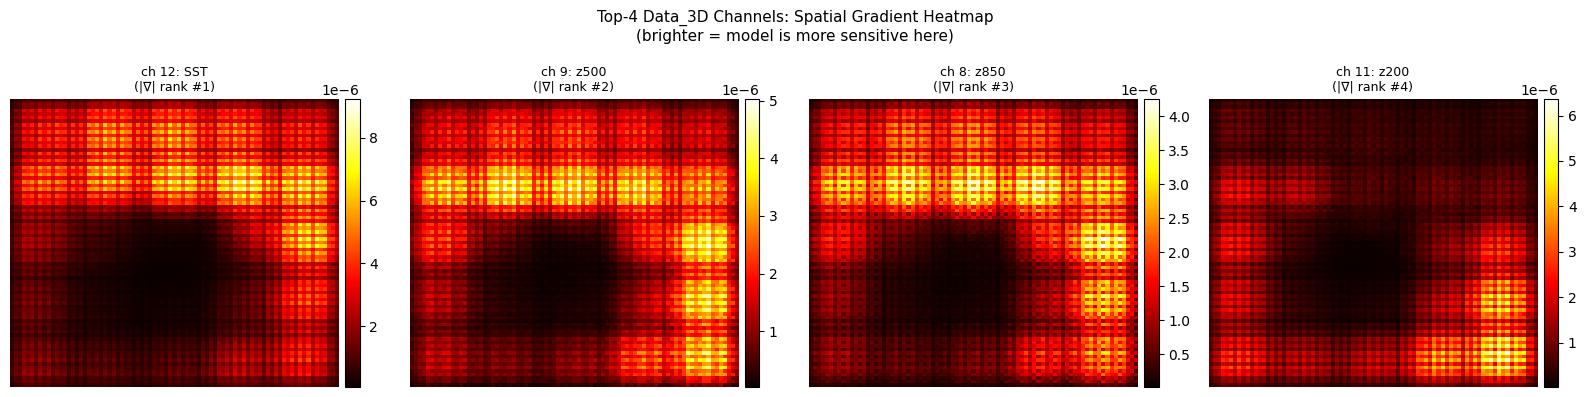

\n=== Feature Importance Summary ===\n
Data_1D (4-dim):
  LAT_norm      0.000192976993  ████████████████████
  LONG_norm     0.000109633569  ███████████
  PRES_norm     0.000050783012  █████
  WND_norm      0.000050414325  █████
\nData_3D top-5 channels:
  #1 SST       0.000002152508  ████████████████████
  #2 z500      0.000001429187  █████████████
  #3 z850      0.000001180611  ██████████
  #4 z200      0.000000981547  █████████
  #5 u500      0.000000764450  ███████
\nEnv-Data top-5 segments:
  #1 Loc.Long      0.000913424010  ████████████████████
  #2 Loc.Lat       0.000836875930  ██████████████████
  #3 Area          0.000756802328  ████████████████
  #4 Month         0.000640109123  ██████████████
  #5 HistInte24    0.000609568786  █████████████


In [24]:
# ── Plot 2: Data_3D — spatial heatmap of gradient per channel ─────────────────
# Shows WHICH REGION in each 81×81 ERA5 patch the model focuses on
if grad_acc['data_3d'] is not None:
    # Pick top-4 most important channels by mean gradient magnitude
    ch_importance = grad_acc['data_3d'].mean(axis=(1,2))
    top4_ch = np.argsort(ch_importance)[::-1][:4]

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, ch in zip(axes, top4_ch):
        spatial_grad = grad_acc['data_3d'][ch]   # (81, 81)
        im = ax.imshow(spatial_grad, cmap='hot', aspect='auto')
        ax.set_title(f'ch {ch}: {CH_NAMES[ch]}\n(|∇| rank #{list(np.argsort(ch_importance)[::-1]).index(ch)+1})',
                     fontsize=9)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
    plt.suptitle('Top-4 Data_3D Channels: Spatial Gradient Heatmap\n'
                 '(brighter = model is more sensitive here)', fontsize=11)
    plt.tight_layout()
    plt.savefig('nb_full_01_3d_spatial_importance.png', dpi=120, bbox_inches='tight')
    plt.show()

# ── Feature importance summary table ──────────────────────────────────────────
print('\\n=== Feature Importance Summary ===\\n')

if grad_acc['data_1d'] is not None:
    imp_1d = grad_acc['data_1d']
    print('Data_1D (4-dim):')
    for nm, v in sorted(zip(D1D_NAMES, imp_1d), key=lambda x: -x[1]):
        bar = '█' * int(v / imp_1d.max() * 20)
        print(f'  {nm:12s}  {v:.12f}  {bar}')

if grad_acc['data_3d'] is not None:
    print('\\nData_3D top-5 channels:')
    for rank, ch in enumerate(np.argsort(ch_importance)[::-1][:5], 1):
        bar = '█' * int(ch_importance[ch] / ch_importance.max() * 20)
        print(f'  #{rank} {CH_NAMES[ch]:8s}  {ch_importance[ch]:.12f}  {bar}')

if grad_acc['env_data'] is not None:
    print('\\nEnv-Data top-5 segments:')
    for rank, idx in enumerate(np.argsort(imp_env_seg)[::-1][:5], 1):
        bar = '█' * int(imp_env_seg[idx] / imp_env_seg.max() * 20)
        print(f'  #{rank} {seg_labels[idx]:12s}  {imp_env_seg[idx]:.12f}  {bar}')

## 9 — Feature Importance Summary

### How it is calculated
For each batch, inputs have `requires_grad_(True)` set. After `loss.backward()`, PyTorch computes
`∂loss/∂input` for each modality. We take the absolute value, average over the batch dimension,
accumulate over 20 batches, and divide by 20. **Higher score = model is more sensitive to that
feature = it matters more.**

---

### Data_1D (position + intensity state)
| Rank | Feature | Score | Interpretation |
|------|---------|-------|----------------|
| 1 | `LAT_norm` | 0.000193 | Storm latitude — dominant |
| 2 | `LONG_norm` | 0.000110 | Storm longitude |
| 3 | `PRES_norm` | 0.000051 | Current pressure |
| 4 | `WND_norm` | 0.000050 | Current wind speed |

**Position (lat/lon) dominates over intensity state (pressure/wind).** After 5 probe epochs the model
is partially learning *where the storm is* rather than *how intense it is*. If this pattern persists
after full training, the model may be shortcutting to geographic climatology instead of physics —
worth monitoring.

---

### Data_3D (ERA5 spatial patches)
| Rank | Channel | Score | Interpretation |
|------|---------|-------|----------------|
| 1 | `SST` | 0.0000022 | Ocean heat content — primary intensification driver |
| 2 | `z500` | 0.0000014 | Mid-level geopotential — large-scale environment |
| 3 | `z850` | 0.0000012 | Low-level geopotential |
| 4 | `z200` | 0.0000010 | Upper-level outflow/divergence |
| 5 | `u500` | 0.0000008 | Mid-level wind |

**SST leading is physically sound** — warmer ocean supplies more energy for intensification.
Geopotential at all three levels (z850/z500/z200) ranking 2–4 means the model reads the large-scale
pressure structure. Wind channels (u/v) are less critical than the pressure environment at this
training stage.

---

### Env-Data (94-dim context vector)
| Rank | Segment | Score | Interpretation |
|------|---------|-------|----------------|
| 1 | `Loc.Long` | 0.000913 | Storm longitude history |
| 2 | `Loc.Lat` | 0.000837 | Storm latitude history |
| 3 | `Area` | 0.000757 | Basin code |
| 4 | `Month` | 0.000640 | Season |
| 5 | `HistInte24` | 0.000610 | Past 24h intensity change |

**Location and basin identity completely dominate** — the top 3 are all geographic.
`HistInte24` at #5 is the first physically meaningful signal: past intensity change predicts
future intensity change (persistence). `Month` at #4 reflects the strong seasonal cycle of TC activity.

---

### Overall Takeaway
After 5 probe epochs, the model is **geography-heavy**. For a well-trained model, `WND_norm`,
`PRES_norm`, `SST`, and `HistInte24` should rank higher relative to raw location features —
those are the physical drivers of intensification. If location still dominates after full training,
consider ablating the location dimensions in `env_data` to test whether the model is learning
physics or just basin climatology.
